In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec
import seaborn as sns
import itertools
import sklearn
import itertools
import scipy
import skimage
import pickle as pkl
from skimage.transform import resize
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import random
random.seed(123)

In [2]:
path1 ="/kaggle/input/kermany2018/OCT2017 /train"
path2 ="/kaggle/input/kermany2018/OCT2017 /test"
path3 ="/kaggle/input/kermany2018/OCT2017 /val"
image_size=(128,128,3)

In [3]:
myList = os.listdir(path1)
print("Total Number of Classes Detected :",len(myList))

Total Number of Classes Detected : 4


In [4]:
random.seed(123)
noOfclasses= len(myList)
print(myList)

['NORMAL', 'DME', 'DRUSEN', 'CNV']


In [5]:
myList=['CNV', 'DME','DRUSEN','NORMAL']
print("Importing Classes...")

Importing Classes...


In [6]:
train_images=[]
train_classNo=[]
CATEGORIES = ['CNV', 'DME','DRUSEN','NORMAL']
for x in myList:
  myPicList = os.listdir(path1+"/"+str(x))
  for y in tqdm(myPicList):
    curImg = cv2.imread(path1+"/"+str(x)+"/"+y)
    curImg = cv2.resize(curImg,(image_size[0],image_size[1]))
    train_images.append(curImg)
    train_classNo.append(CATEGORIES.index(x))
  print(x)

  0%|          | 0/11348 [00:00<?, ?it/s]

CNV


  0%|          | 0/8616 [00:00<?, ?it/s]

DME


100%|██████████| 8616/8616 [01:06<00:00, 129.55it/s]


DRUSEN


100%|██████████| 26315/26315 [03:29<00:00, 125.76it/s]

NORMAL


In [7]:
test_images=[]
test_classNo=[]
CATEGORIES = ['CNV', 'DME','DRUSEN','NORMAL']
for x in myList:
  myPicList = os.listdir(path2+"/"+str(x))
  for y in myPicList:
    curImg = cv2.imread(path2+"/"+str(x)+"/"+y)
    curImg = cv2.resize(curImg,(image_size[0],image_size[1]))
    test_images.append(curImg)
    test_classNo.append(CATEGORIES.index(x))
  print(x)

CNV
DME
DRUSEN
NORMAL


In [8]:
x_train = np.array(train_images)
y_train = np.array(train_classNo)

In [9]:
del train_images
del train_classNo

In [10]:
x_test = np.array(test_images)
y_test = np.array(test_classNo)

In [11]:
del test_images
del test_classNo

{0: 'CNV', 1: 'DME', 2: 'DRUSEN', 3: 'NORMAL'}


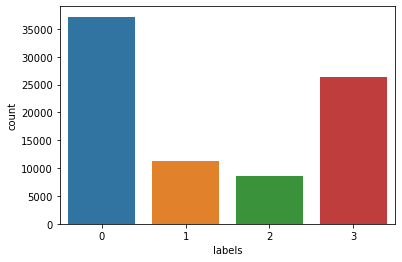

In [12]:
map_characters = {0: 'CNV', 1: 'DME', 2:'DRUSEN' , 3:'NORMAL' }
dict_characters=map_characters
import seaborn as sns
df = pd.DataFrame()
df["labels"]=y_train
lab = df['labels']
dist = lab.value_counts()
sns.countplot(lab)
print(dict_characters)

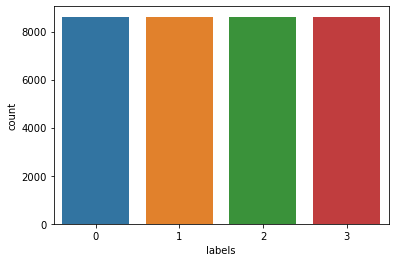

In [13]:
from keras.utils.np_utils import to_categorical
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import seaborn as sns
X_trainShape = x_train.shape[1]*x_train.shape[2]*x_train.shape[3]
X_trainFlat = x_train.reshape(x_train.shape[0], X_trainShape)
Y_train = y_train

ros = RandomUnderSampler()
X_trainRos, Y_trainRos = ros.fit_sample(X_trainFlat, Y_train)
Y_train_ros = to_categorical(Y_trainRos,noOfclasses)
# Make Data 2D again
for i in range(len(X_trainRos)):
    height, width, channels = image_size[0],image_size[1],3
    X_trainRosReshaped = X_trainRos.reshape(len(X_trainRos),height,width,channels)
# Plot Label Distribution
dfRos = pd.DataFrame()
dfRos["labels"]=Y_trainRos
labRos = dfRos['labels']
sns.countplot(labRos)

In [14]:
from sklearn.utils import shuffle
X_trainRosReshaped,Y_train_ros = shuffle(X_trainRosReshaped,Y_train_ros, random_state=123)

In [15]:
with open("train_all.pkl", "wb") as f:
    pkl.dump([X_trainRosReshaped,Y_train_ros], f)